In [13]:
import pandas as pd
import matplotlib.pyplot as plt

df_tesla = pd.read_csv('data/TESLA Search Trend vs Price.csv')
df_btc_search = pd.read_csv('data/Bitcoin Search Trend.csv')
df_btc_price = pd.read_csv('data/Daily Bitcoin Price.csv')
df_unemployment = pd.read_csv('data/UE Benefits Search vs UE Rate 2004-19.csv')

In [14]:
print(df_tesla.shape)
df_tesla.head()

(124, 3)


,MONTH,TSLA_WEB_SEARCH,TSLA_USD_CLOSE
0,2010-06-01,3,4.766
1,2010-07-01,3,3.988
2,2010-08-01,2,3.896
3,2010-09-01,2,4.082
4,2010-10-01,2,4.368


In [15]:
print(f'Largest value for Tesla in Web Search : {df_tesla.TSLA_WEB_SEARCH.max()}')
print(f'Smallest value for Tesla in Web Search : {df_tesla.TSLA_WEB_SEARCH.min()}')

df_tesla.describe()

Largest value for Tesla in Web Search : 31
Smallest value for Tesla in Web Search : 2


,TSLA_WEB_SEARCH,TSLA_USD_CLOSE
count,124.000000,124.000000
mean,8.725806,50.962145
std,5.870332,65.908389
min,2.000000,3.896000
25%,3.750000,7.352500
50%,8.000000,44.653000
75%,12.000000,58.991999
max,31.000000,498.320007


In [16]:
print(df_unemployment.shape)
df_unemployment.head()

(181, 3)


,MONTH,UE_BENEFITS_WEB_SEARCH,UNRATE
0,2004-01,34,5.7
1,2004-02,33,5.6
2,2004-03,25,5.8
3,2004-04,29,5.6
4,2004-05,23,5.6


In [17]:
print(f'Largest value for Unemployment Benefits in Web Search : {df_unemployment.UE_BENEFITS_WEB_SEARCH.max()}')

Largest value for Unemployment Benefits in Web Search : 100


In [18]:
print(df_btc_price.shape)
df_btc_price.head()

(2204, 3)


,DATE,CLOSE,VOLUME
0,2014-09-17,457.334015,21056800.0
1,2014-09-18,424.440002,34483200.0
2,2014-09-19,394.795990,37919700.0
3,2014-09-20,408.903992,36863600.0
4,2014-09-21,398.821014,26580100.0


In [19]:
print(df_btc_search.shape)
df_btc_search.head()

(73, 2)


,MONTH,BTC_NEWS_SEARCH
0,2014-09,5
1,2014-10,4
2,2014-11,4
3,2014-12,4
4,2015-01,5


In [20]:
print(f'Largest value for BTC News Search : {df_btc_search.BTC_NEWS_SEARCH.max()}')

Largest value for BTC News Search : 100


In [21]:
print(f'Missing values for Tesla? : {df_tesla.isna().values.any()}')
print(f'Missing values for UE? : {df_unemployment.isna().values.any()}')
print(f'Missing values for BTC price? : {df_btc_price.isna().values.any()}')
print(f'Missing values for BTC search? : {df_btc_search.isna().values.any()}')

Missing values for Tesla? : False
Missing values for UE? : False
Missing values for BTC price? : True
Missing values for BTC search? : False


In [22]:
print(f'How many missing values for BTC price? : {df_btc_price.isna().values.sum()}')
df_btc_price[df_btc_price.CLOSE.isna()]

How many missing values for BTC price? : 2


,DATE,CLOSE,VOLUME
2148,2020-08-04,NaN,NaN


In [23]:
df_btc_price.dropna(inplace=True)

In [24]:
df_tesla.MONTH = pd.to_datetime(df_tesla.MONTH)
df_btc_search.MONTH = pd.to_datetime(df_btc_search.MONTH)
df_unemployment.MONTH = pd.to_datetime(df_unemployment.MONTH)
df_btc_price.DATE = pd.to_datetime(df_btc_price.DATE)

df_tesla.MONTH.head()

0   2010-06-01
1   2010-07-01
2   2010-08-01
3   2010-09-01
4   2010-10-01
Name: MONTH, dtype: datetime64[ns]

In [27]:
df_btc_monthly = df_btc_price.resample('ME', on='DATE').last()
print(df_btc_monthly.shape)

df_btc_monthly.head()

(73, 2)


,CLOSE,VOLUME
DATE,,
2014-09-30,386.944000,34707300.0
2014-10-31,338.321014,12545400.0
2014-11-30,378.046997,9194440.0
2014-12-31,320.192993,13942900.0
2015-01-31,217.464005,23348200.0


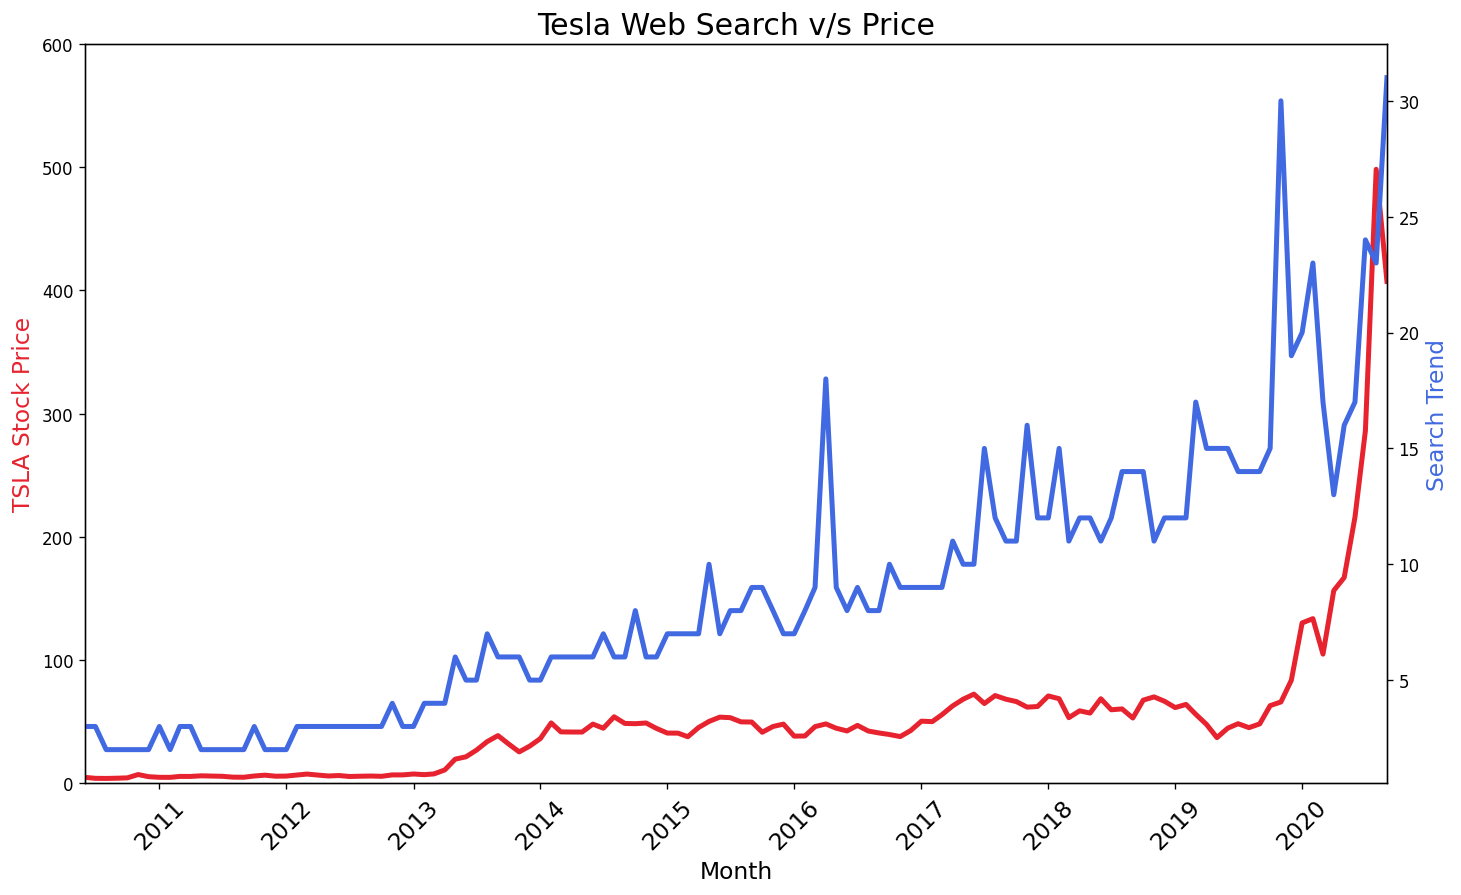

In [33]:
plt.figure(figsize=(14,8), dpi=120)
plt.title('Tesla Web Search v/s Price', fontsize=18)

plt.xticks(fontsize=14, rotation=45)

ax_stock_price = plt.gca()
ax_search_trend = ax_stock_price.twinx()

ax_stock_price.set_ylabel('TSLA Stock Price', color='#E6232E', fontsize=14)
ax_search_trend.set_ylabel('Search Trend', color='royalblue', fontsize=14)

ax_stock_price.set_ylim([0, 600])
ax_stock_price.set_xlim([df_tesla.MONTH.min(), df_tesla.MONTH.max()]) 

ax_stock_price.set_xlabel('Month', fontsize=14) 

ax_stock_price.plot(df_tesla.MONTH, df_tesla.TSLA_USD_CLOSE, color='#E6232E', linewidth=3)
ax_search_trend.plot(df_tesla.MONTH, df_tesla.TSLA_WEB_SEARCH, color='royalblue', linewidth=3)

plt.show()

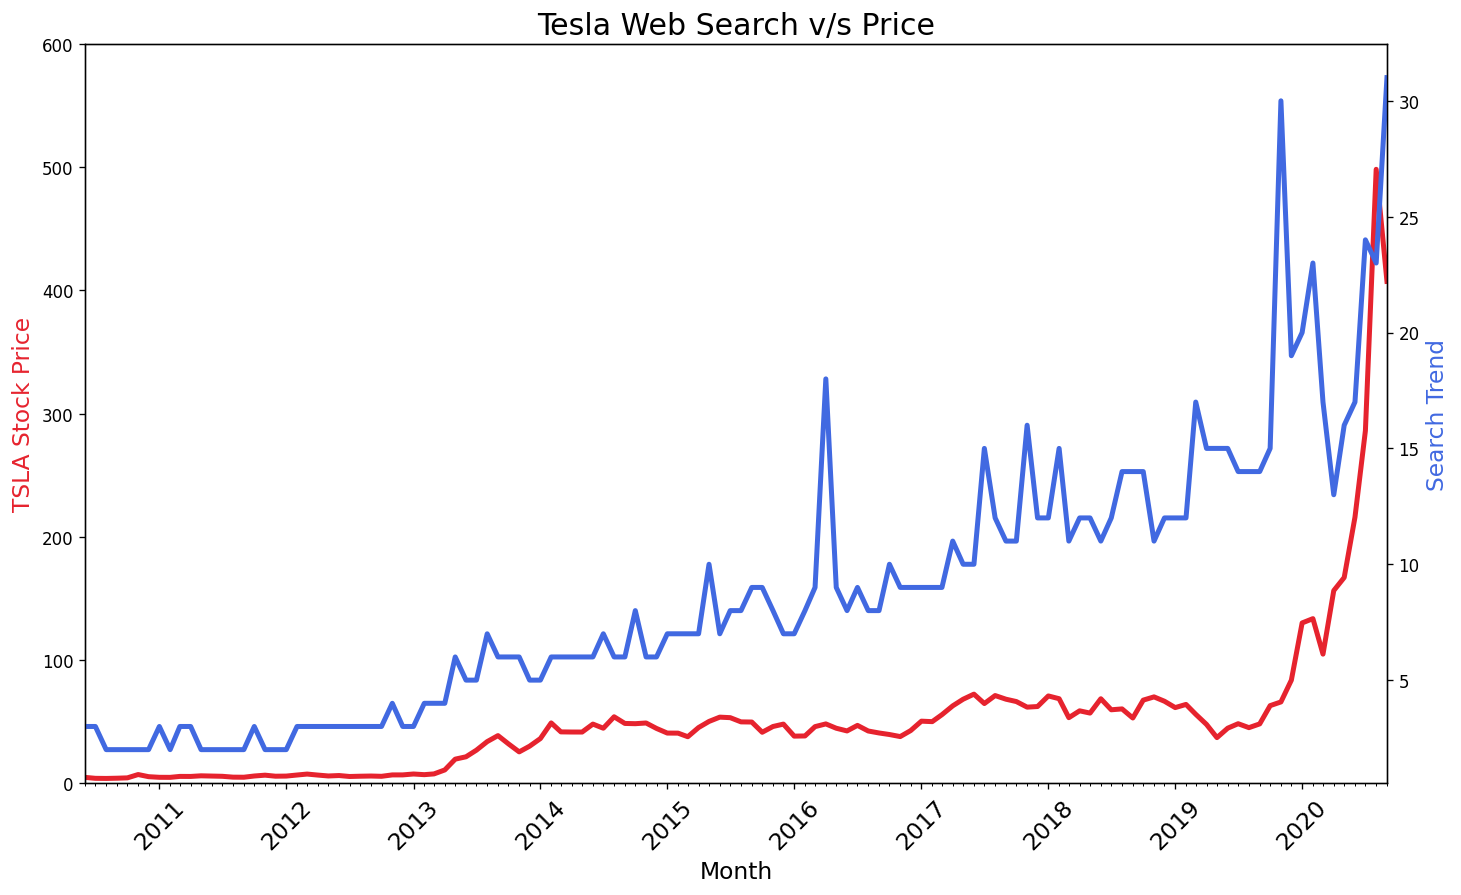

In [34]:
import matplotlib.dates as mdates

years = mdates.YearLocator()
months = mdates.MonthLocator()
years_fmt = mdates.DateFormatter('%Y')

plt.figure(figsize=(14,8), dpi=120)
plt.title('Tesla Web Search v/s Price', fontsize=18)

plt.xticks(fontsize=14, rotation=45)

ax_stock_price = plt.gca()
ax_search_trend = ax_stock_price.twinx()

ax_stock_price.xaxis.set_major_locator(years)
ax_stock_price.xaxis.set_major_formatter(years_fmt)
ax_stock_price.xaxis.set_minor_locator(months)

ax_stock_price.set_ylabel('TSLA Stock Price', color='#E6232E', fontsize=14)
ax_search_trend.set_ylabel('Search Trend', color='royalblue', fontsize=14)

ax_stock_price.set_ylim([0, 600])
ax_stock_price.set_xlim([df_tesla.MONTH.min(), df_tesla.MONTH.max()]) 

ax_stock_price.set_xlabel('Month', fontsize=14) 

ax_stock_price.plot(df_tesla.MONTH, df_tesla.TSLA_USD_CLOSE, color='#E6232E', linewidth=3)
ax_search_trend.plot(df_tesla.MONTH, df_tesla.TSLA_WEB_SEARCH, color='royalblue', linewidth=3)

plt.show()

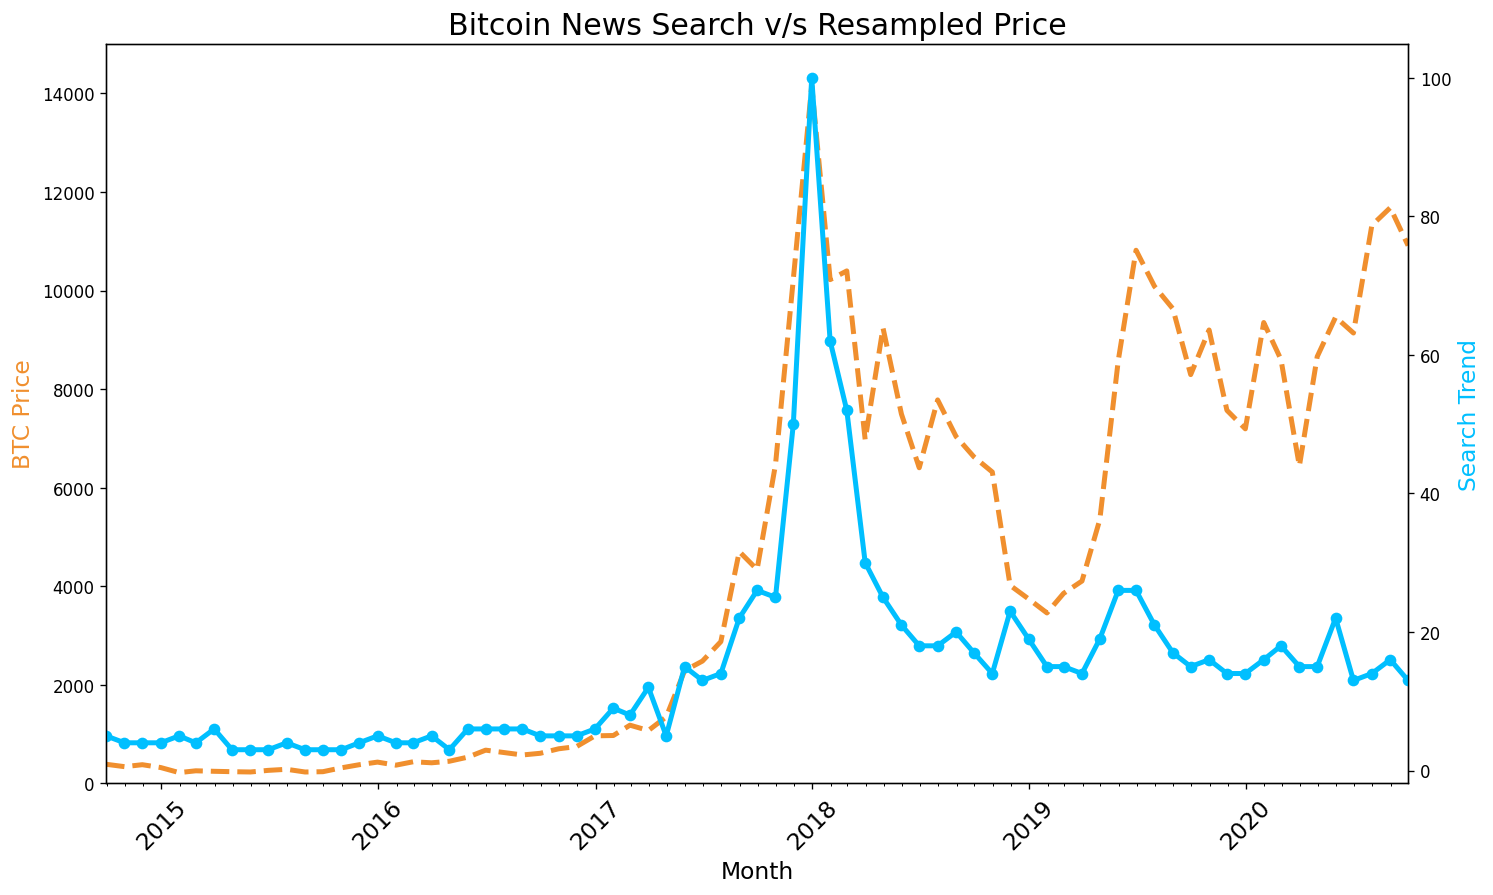

In [37]:
import matplotlib.dates as mdates

years = mdates.YearLocator()
months = mdates.MonthLocator()
years_fmt = mdates.DateFormatter('%Y')

plt.figure(figsize=(14,8), dpi=120)
plt.title('Bitcoin News Search v/s Resampled Price', fontsize=18)

plt.xticks(fontsize=14, rotation=45)

ax_btc_price = plt.gca()
ax_search_trend = ax_btc_price.twinx()

ax_btc_price.xaxis.set_major_locator(years)
ax_btc_price.xaxis.set_major_formatter(years_fmt)
ax_btc_price.xaxis.set_minor_locator(months)

ax_btc_price.set_ylabel('BTC Price', color='#F08F2E', fontsize=14)
ax_search_trend.set_ylabel('Search Trend', color='deepskyblue', fontsize=14)

ax_btc_price.set_ylim(bottom=0, top=15000)
ax_btc_price.set_xlim([df_btc_monthly.index.min(), df_btc_monthly.index.max()]) 

ax_btc_price.set_xlabel('Month', fontsize=14) 

ax_btc_price.plot(df_btc_monthly.index, df_btc_monthly.CLOSE, color='#F08F2E', linewidth=3, linestyle='--')
ax_search_trend.plot(df_btc_monthly.index, df_btc_search.BTC_NEWS_SEARCH, color='deepskyblue', linewidth=3, marker='o')

plt.show()